In [33]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

from scripts.notebook_setup import setup, OKABE_ITO_CYCLE
PROJECT_ROOT, np, pd, plt, Path = setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


In [34]:
# Path to AFM data file
AFM_FILE = PROJECT_ROOT / "data" / "AFM" / "FGT-CPS-(device-2)" / "FGT_thickness.XYZ"

# Load: columns are [x (m), y (m), z (m)]
data = np.loadtxt(AFM_FILE)
x_raw, y_raw, z_raw = data[:, 0], data[:, 1], data[:, 2]

# Convert to µm (x, y) and nm (z)
x_um = x_raw * 1e6
y_um = y_raw * 1e6
z_nm = z_raw * 1e9

# Infer grid dimensions from unique coordinate values
x_unique = np.unique(x_um)
y_unique = np.unique(y_um)
nx, ny = len(x_unique), len(y_unique)
print(f"Grid: {nx} x-points × {ny} y-points")
print(f"Scan range: {x_unique[0]:.3f}–{x_unique[-1]:.3f} µm  ×  {y_unique[0]:.3f}–{y_unique[-1]:.3f} µm")
print(f"Height range: {z_nm.min():.1f}–{z_nm.max():.1f} nm")

# Reshape z into a 2D array (ny rows × nx columns)
Z = z_nm.reshape(ny, nx)

Grid: 310 x-points × 296 y-points
Scan range: 0.003–2.035 µm  ×  0.003–1.943 µm
Height range: 0.0–58.6 nm


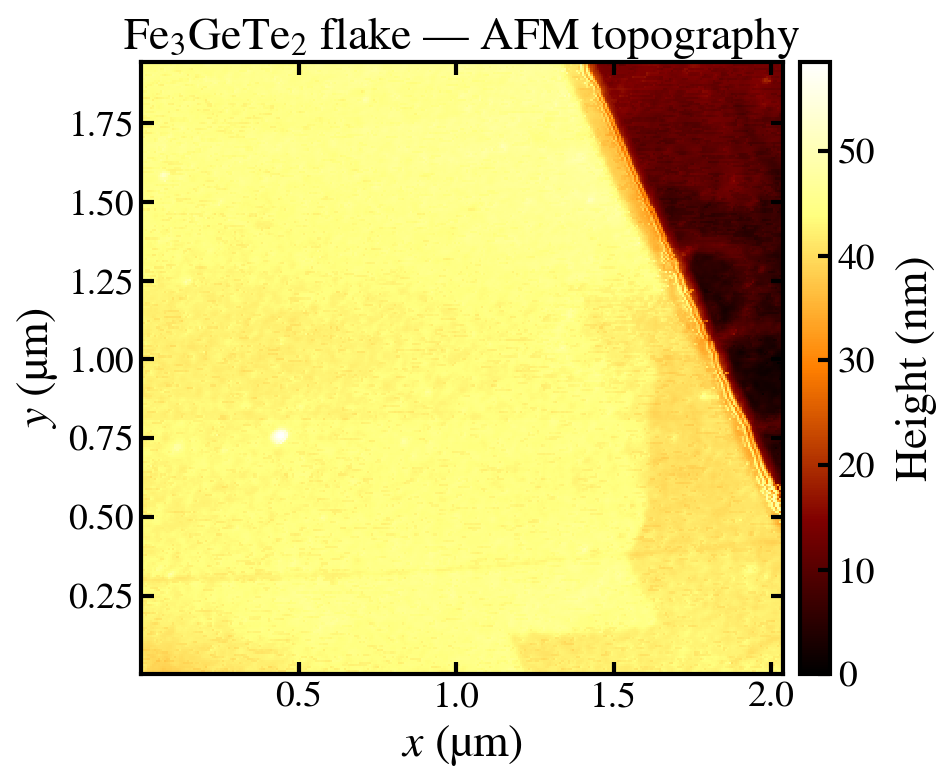

In [35]:
# --- AFM height map ---
fig, ax = plt.subplots(figsize=(7, 5.5))

im = ax.pcolormesh(
    x_unique, y_unique, Z,
    cmap="afmhot",
    shading="nearest",
    rasterized=True,
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Height (nm)", labelpad=10)

ax.set_xlabel(r"$x$ (µm)")
ax.set_ylabel(r"$y$ (µm)")
ax.set_title(r"Fe$_3$GeTe$_2$ flake — AFM topography")
ax.set_aspect("equal")

fig.tight_layout()
plt.show()

In [36]:
# ── Linecut coordinates — edit these ─────────────────────────────────────────
X0, Y0 = 1.2,  1.75   # start point (µm)
X1, Y1 = 1.8, 1.75   # end   point (µm)

Linecut: (1.2, 1.75) → (1.8, 1.75) µm  |  93 pixels sampled


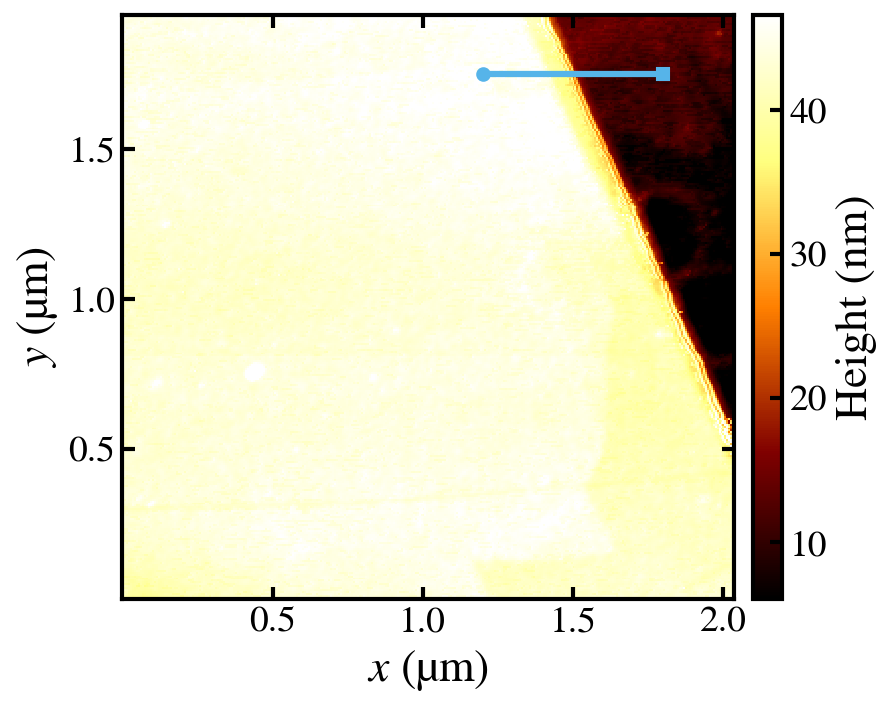

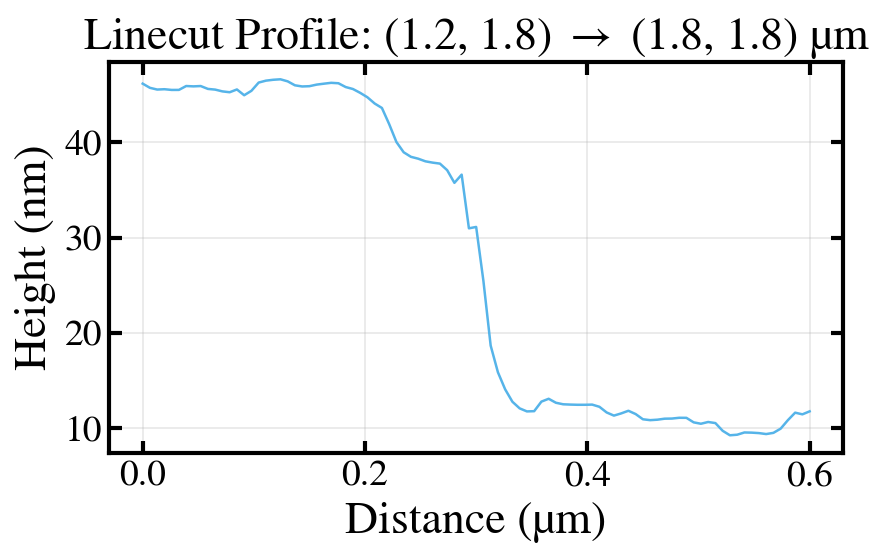

In [37]:
from scipy.interpolate import RegularGridInterpolator

# Pixel spacings (µm)
dx_um = x_unique[1] - x_unique[0]
dy_um = y_unique[1] - y_unique[0]

# Number of samples = Euclidean length of the line in pixel units
# ensures one sample per pixel along the path — not a user variable
n_points = int(np.ceil(np.hypot((X1 - X0) / dx_um, (Y1 - Y0) / dy_um))) + 1

# Build interpolator (y axis first — row-major)
interp = RegularGridInterpolator(
    (y_unique, x_unique), Z,
    method="linear", bounds_error=True,
)

# Sample points along the line
t = np.linspace(0, 1, n_points)
xs = X0 + t * (X1 - X0)
ys = Y0 + t * (Y1 - Y0)
z_line = interp(np.column_stack([ys, xs]))
d_line = t * np.hypot(X1 - X0, Y1 - Y0)   # distance in µm

print(f"Linecut: ({X0}, {Y0}) → ({X1}, {Y1}) µm  |  {n_points} pixels sampled")

# --- Figure 1: Map with Linecut Overlaid ---
fig1, ax_map = plt.subplots(figsize=(7, 5))

im = ax_map.pcolormesh(
    x_unique, y_unique, Z,
    cmap="afmhot", shading="nearest",
    vmin=z_p2, vmax=z_p98,
    rasterized=True,
)

# Colorbar for the first figure
fig1.colorbar(im, ax=ax_map, pad=0.02, label="Height (nm)")

# Drawing the linecut path
ax_map.plot([X0, X1], [Y0, Y1], color="#56B4E9", lw=3, zorder=5)
ax_map.plot(X0, Y0, "o", color="#56B4E9", ms=6, zorder=6) # Start
ax_map.plot(X1, Y1, "s", color="#56B4E9", ms=6, zorder=6) # End

ax_map.set_xlabel(r"$x$ (µm)")
ax_map.set_ylabel(r"$y$ (µm)")
ax_map.set_aspect("equal")

fig1.tight_layout()
plt.show()

# --- Figure 2: Height Profile (Linecut) ---
fig2, ax_prof = plt.subplots(figsize=(6, 4))

ax_prof.plot(d_line, z_line, color="#56B4E9", lw=1.2)
ax_prof.set_xlabel(r"Distance (µm)")
ax_prof.set_ylabel(r"Height (nm)")

# Dynamic title based on coordinates
ax_prof.set_title(
    rf"Linecut Profile: ({X0:.1f}, {Y0:.1f}) $\to$ ({X1:.1f}, {Y1:.1f}) µm"
)

ax_prof.grid(True, alpha=0.3) # Added a subtle grid for better readability
fig2.tight_layout()
plt.show()

In [38]:
# ── Flat-region definitions — distance along the linecut (µm) ────────────────
# Each tuple is (d_start, d_end): the portion of the 1-D profile that is flat.
# Order from lowest to highest level.
FLAT_REGIONS = [
    (0.0, 0.2),    # level 1 
    (0.4, 0.6),    # level 2 ]
]
# Which region's slope is used to correct the whole linecut tilt (0-based index)
TILT_REF_IDX = 1

Tilt removed: -10.417 nm/µm
  Level 1: 41.7 ± 0.8 nm
  Level 2: 10.7 ± 0.7 nm
  Δ(level 2 − level 1) = -30.9 nm


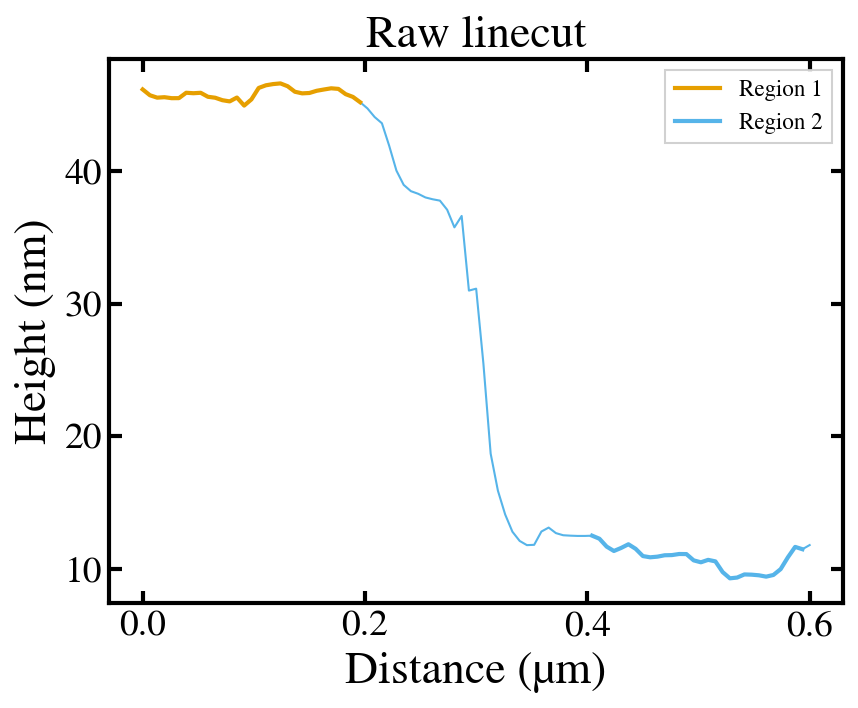

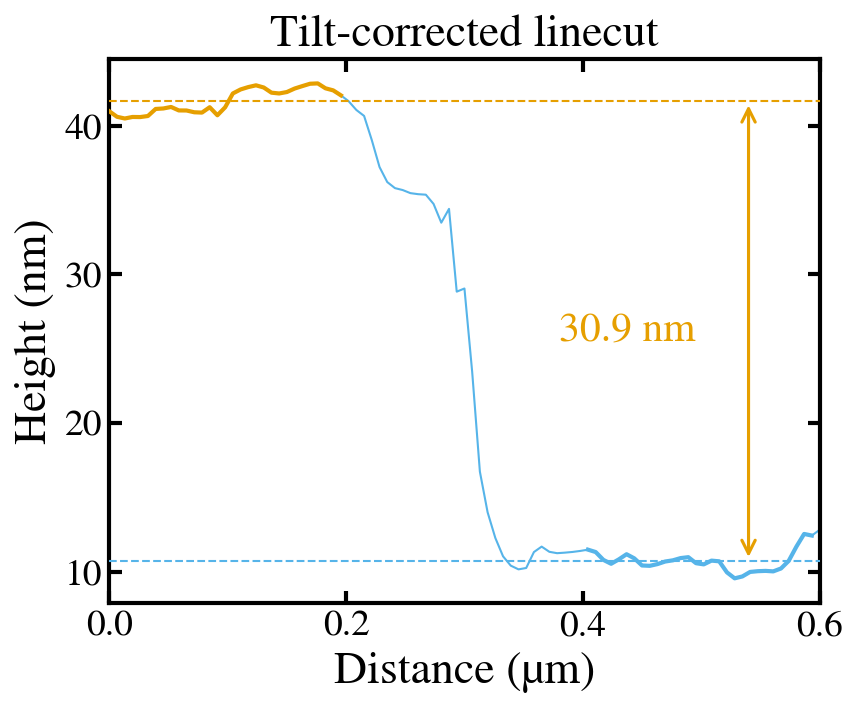

In [39]:
from scipy.stats import linregress

# ── 1. Tilt correction ────────────────────────────────────────────────────────
d0_ref, d1_ref = FLAT_REGIONS[TILT_REF_IDX]
mask_ref = (d_line >= d0_ref) & (d_line <= d1_ref)
slope, *_ = linregress(d_line[mask_ref], z_line[mask_ref])

# Subtract slope, anchored at the reference region centre (height preserved there)
d_anchor = d_line[mask_ref].mean()
z_corr = z_line - slope * (d_line - d_anchor)

# ── 2. Mean height per flat region (after correction) ────────────────────────
masks = [(d_line >= d0) & (d_line <= d1) for d0, d1 in FLAT_REGIONS]
means = [z_corr[m].mean() for m in masks]
stds  = [z_corr[m].std()  for m in masks]

print(f"Tilt removed: {slope:.3f} nm/µm")
for i, (mean, std) in enumerate(zip(means, stds)):
    print(f"  Level {i+1}: {mean:.1f} ± {std:.1f} nm")
for i in range(len(means) - 1):
    print(f"  Δ(level {i+2} − level {i+1}) = {means[i+1] - means[i]:.1f} nm")

# ── 3. Figure 1: raw linecut with flat regions highlighted ───────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.plot(d_line, z_line, color="#56B4E9", lw=1.0, zorder=2)
for i, (d0, d1) in enumerate(FLAT_REGIONS):
    mask = (d_line >= d0) & (d_line <= d1)
    ax1.plot(d_line[mask], z_line[mask],
             color=OKABE_ITO_CYCLE[i], lw=2.0, zorder=3,
             label=f"Region {i+1}")
ax1.set_xlabel("Distance (µm)")
ax1.set_ylabel("Height (nm)")
ax1.set_title("Raw linecut")
ax1.legend(fontsize=11)
fig1.tight_layout()
plt.show()

# ── 4. Figure 2: tilt-corrected linecut with level annotations ───────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.plot(d_line, z_corr, color="#56B4E9", lw=1.0, zorder=2)
for i, (d0, d1) in enumerate(FLAT_REGIONS):
    mask = (d_line >= d0) & (d_line <= d1)
    ax2.plot(d_line[mask], z_corr[mask],
             color=OKABE_ITO_CYCLE[i], lw=2.0, zorder=3,
             label=f"Region {i+1}")

# Dashed level lines and step arrows
arrow_x = d_line[-1] * 0.9
for i, mean in enumerate(means):
    ax2.axhline(mean, ls="--", lw=1.0, color=OKABE_ITO_CYCLE[i], zorder=3)
    
for i in range(len(means) - 1):
    z_lo, z_hi = means[i], means[i + 1]
    ax2.annotate("", xy=(arrow_x, z_hi), xytext=(arrow_x, z_lo),
                 arrowprops=dict(arrowstyle="<->", color=OKABE_ITO_CYCLE[i], lw=1.5))
    ax2.text(arrow_x-0.16, (z_lo + z_hi) / 2,
             f"{z_lo - z_hi:.1f} nm",
             va="center", ha="left", color=OKABE_ITO_CYCLE[i], fontsize=20)

ax2.set_xlim(d_line[0], d_line[-1])
ax2.set_xlabel("Distance (µm)")
ax2.set_ylabel("Height (nm)")
ax2.set_title("Tilt-corrected linecut")
fig2.tight_layout()
plt.show()

In [40]:
# Path to AFM data file
AFM_FILE = PROJECT_ROOT / "data" / "AFM" / "FGT-CPS-(device-2)" / "CPS_thickness.XYZ"

# Load: columns are [x (m), y (m), z (m)]
data = np.loadtxt(AFM_FILE)
x_raw, y_raw, z_raw = data[:, 0], data[:, 1], data[:, 2]

# Convert to µm (x, y) and nm (z)
x_um = x_raw * 1e6
y_um = y_raw * 1e6
z_nm = z_raw * 1e9

# Infer grid dimensions from unique coordinate values
x_unique = np.unique(x_um)
y_unique = np.unique(y_um)
nx, ny = len(x_unique), len(y_unique)
print(f"Grid: {nx} x-points × {ny} y-points")
print(f"Scan range: {x_unique[0]:.3f}–{x_unique[-1]:.3f} µm  ×  {y_unique[0]:.3f}–{y_unique[-1]:.3f} µm")
print(f"Height range: {z_nm.min():.1f}–{z_nm.max():.1f} nm")

# Reshape z into a 2D array (ny rows × nx columns)
Z = z_nm.reshape(ny, nx)

Grid: 354 x-points × 268 y-points
Scan range: 0.010–7.080 µm  ×  0.010–5.357 µm
Height range: -12.4–182.0 nm


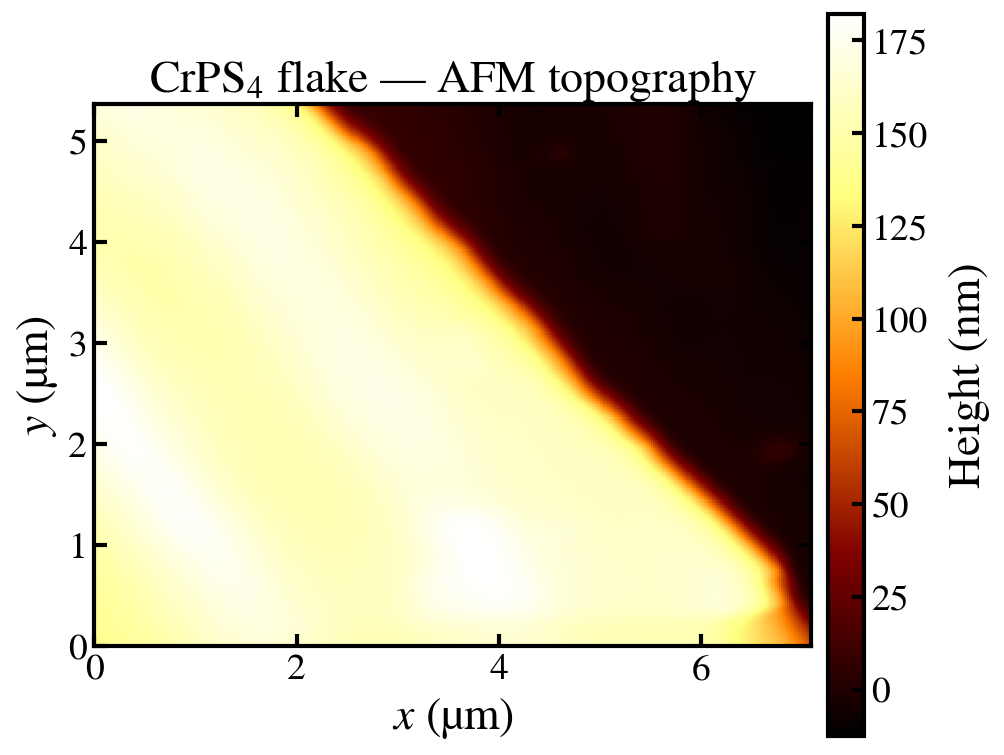

In [41]:
# --- AFM height map ---
fig, ax = plt.subplots(figsize=(7, 5.5))

im = ax.pcolormesh(
    x_unique, y_unique, Z,
    cmap="afmhot",
    shading="nearest",
    rasterized=True,
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Height (nm)", labelpad=10)

ax.set_xlabel(r"$x$ (µm)")
ax.set_ylabel(r"$y$ (µm)")
ax.set_title(r"CrPS$_4$ flake — AFM topography")
ax.set_aspect("equal")

fig.tight_layout()
plt.show()

In [42]:
# ── Linecut coordinates — edit these ─────────────────────────────────────────
X0, Y0 = 3.5,  3   # start point (µm)
X1, Y1 = 5, 4   # end   point (µm)

Linecut: (3.5, 3) → (5, 4) µm  |  92 pixels sampled


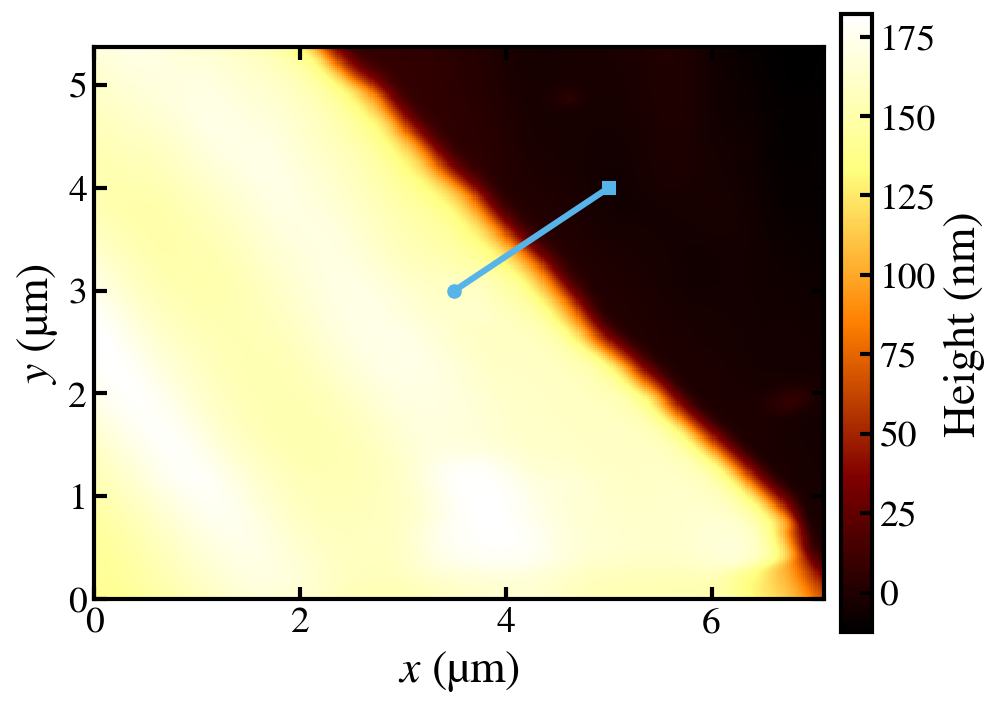

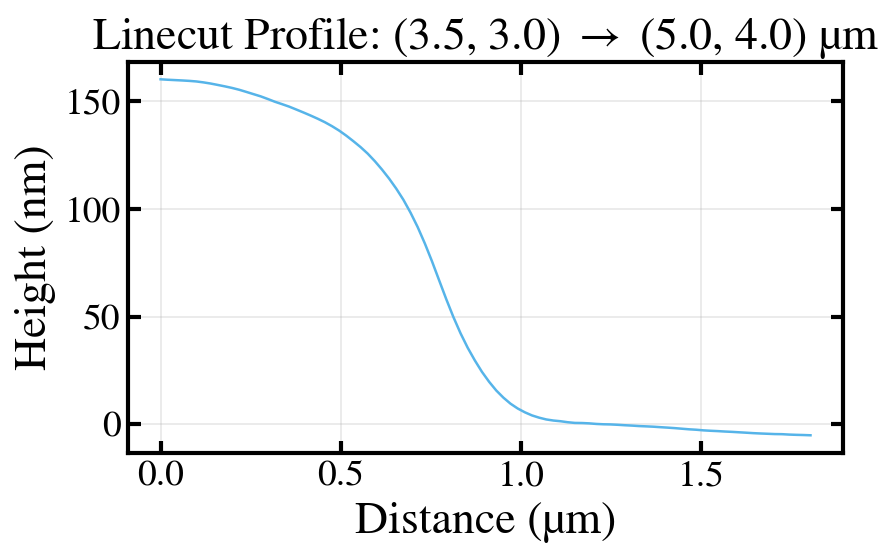

In [46]:
from scipy.interpolate import RegularGridInterpolator

# Pixel spacings (µm)
dx_um = x_unique[1] - x_unique[0]
dy_um = y_unique[1] - y_unique[0]

# Number of samples = Euclidean length of the line in pixel units
# ensures one sample per pixel along the path — not a user variable
n_points = int(np.ceil(np.hypot((X1 - X0) / dx_um, (Y1 - Y0) / dy_um))) + 1

# Build interpolator (y axis first — row-major)
interp = RegularGridInterpolator(
    (y_unique, x_unique), Z,
    method="linear", bounds_error=True,
)

# Sample points along the line
t = np.linspace(0, 1, n_points)
xs = X0 + t * (X1 - X0)
ys = Y0 + t * (Y1 - Y0)
z_line = interp(np.column_stack([ys, xs]))
d_line = t * np.hypot(X1 - X0, Y1 - Y0)   # distance in µm

print(f"Linecut: ({X0}, {Y0}) → ({X1}, {Y1}) µm  |  {n_points} pixels sampled")

# --- Figure 1: Map with Linecut Overlaid ---
fig1, ax_map = plt.subplots(figsize=(7, 5))

im = ax_map.pcolormesh(
    x_unique, y_unique, Z,
    cmap="afmhot", shading="nearest",
    rasterized=True,
)

# Colorbar for the first figure
fig1.colorbar(im, ax=ax_map, pad=0.02, label="Height (nm)")

# Drawing the linecut path
ax_map.plot([X0, X1], [Y0, Y1], color="#56B4E9", lw=3, zorder=5)
ax_map.plot(X0, Y0, "o", color="#56B4E9", ms=6, zorder=6) # Start
ax_map.plot(X1, Y1, "s", color="#56B4E9", ms=6, zorder=6) # End

ax_map.set_xlabel(r"$x$ (µm)")
ax_map.set_ylabel(r"$y$ (µm)")
ax_map.set_aspect("equal")

fig1.tight_layout()
plt.show()

# --- Figure 2: Height Profile (Linecut) ---
fig2, ax_prof = plt.subplots(figsize=(6, 4))

ax_prof.plot(d_line, z_line, color="#56B4E9", lw=1.2)
ax_prof.set_xlabel(r"Distance (µm)")
ax_prof.set_ylabel(r"Height (nm)")

# Dynamic title based on coordinates
ax_prof.set_title(
    rf"Linecut Profile: ({X0:.1f}, {Y0:.1f}) $\to$ ({X1:.1f}, {Y1:.1f}) µm"
)

ax_prof.grid(True, alpha=0.3) # Added a subtle grid for better readability
fig2.tight_layout()
plt.show()

In [47]:
# ── Flat-region definitions — distance along the linecut (µm) ────────────────
# Each tuple is (d_start, d_end): the portion of the 1-D profile that is flat.
# Order from lowest to highest level.
FLAT_REGIONS = [
    (0.0, 0.5),    # level 1 
    (1.0, 1.6),    # level 2 ]
]
# Which region's slope is used to correct the whole linecut tilt (0-based index)
TILT_REF_IDX = 1

Tilt removed: -12.248 nm/µm
  Level 1: 139.1 ± 5.6 nm
  Level 2: -0.3 ± 0.6 nm
  Δ(level 2 − level 1) = -139.5 nm


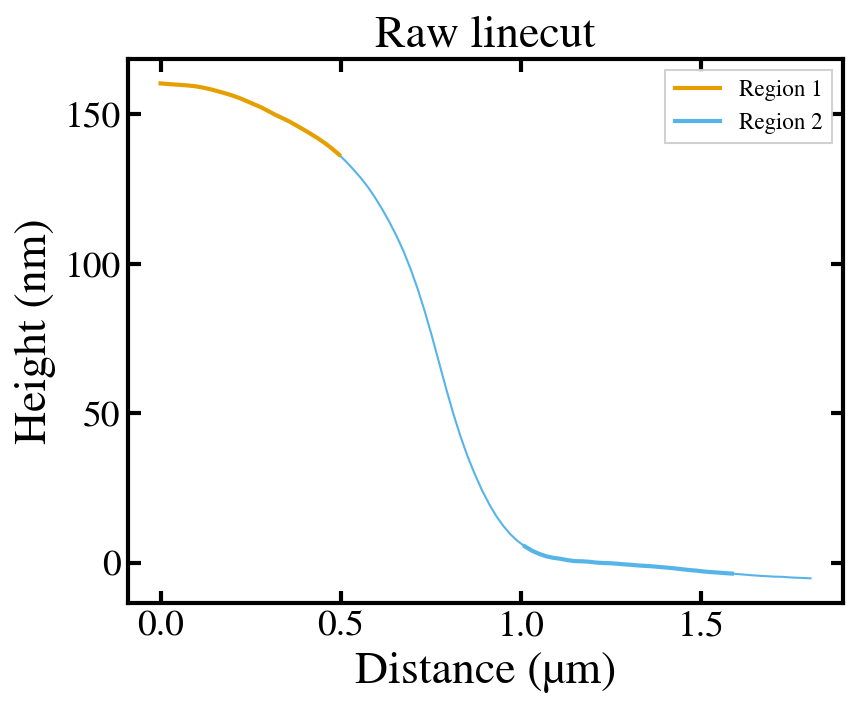

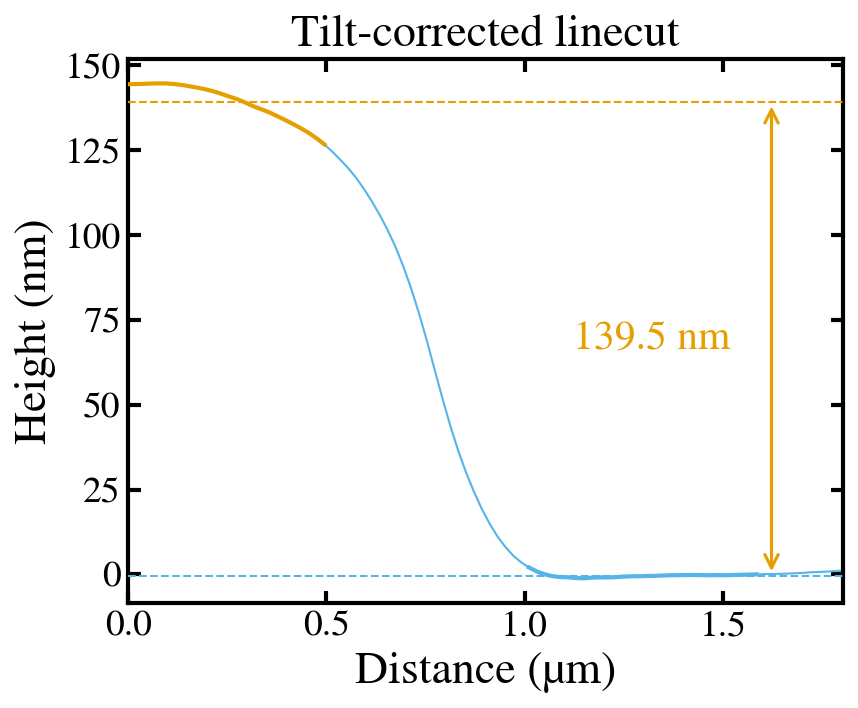

In [53]:
from scipy.stats import linregress

# ── 1. Tilt correction ────────────────────────────────────────────────────────
d0_ref, d1_ref = FLAT_REGIONS[TILT_REF_IDX]
mask_ref = (d_line >= d0_ref) & (d_line <= d1_ref)
slope, *_ = linregress(d_line[mask_ref], z_line[mask_ref])

# Subtract slope, anchored at the reference region centre (height preserved there)
d_anchor = d_line[mask_ref].mean()
z_corr = z_line - slope * (d_line - d_anchor)

# ── 2. Mean height per flat region (after correction) ────────────────────────
masks = [(d_line >= d0) & (d_line <= d1) for d0, d1 in FLAT_REGIONS]
means = [z_corr[m].mean() for m in masks]
stds  = [z_corr[m].std()  for m in masks]

print(f"Tilt removed: {slope:.3f} nm/µm")
for i, (mean, std) in enumerate(zip(means, stds)):
    print(f"  Level {i+1}: {mean:.1f} ± {std:.1f} nm")
for i in range(len(means) - 1):
    print(f"  Δ(level {i+2} − level {i+1}) = {means[i+1] - means[i]:.1f} nm")

# ── 3. Figure 1: raw linecut with flat regions highlighted ───────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.plot(d_line, z_line, color="#56B4E9", lw=1.0, zorder=2)
for i, (d0, d1) in enumerate(FLAT_REGIONS):
    mask = (d_line >= d0) & (d_line <= d1)
    ax1.plot(d_line[mask], z_line[mask],
             color=OKABE_ITO_CYCLE[i], lw=2.0, zorder=3,
             label=f"Region {i+1}")
ax1.set_xlabel("Distance (µm)")
ax1.set_ylabel("Height (nm)")
ax1.set_title("Raw linecut")
ax1.legend(fontsize=11)
fig1.tight_layout()
plt.show()

# ── 4. Figure 2: tilt-corrected linecut with level annotations ───────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.plot(d_line, z_corr, color="#56B4E9", lw=1.0, zorder=2)
for i, (d0, d1) in enumerate(FLAT_REGIONS):
    mask = (d_line >= d0) & (d_line <= d1)
    ax2.plot(d_line[mask], z_corr[mask],
             color=OKABE_ITO_CYCLE[i], lw=2.0, zorder=3,
             label=f"Region {i+1}")

# Dashed level lines and step arrows
arrow_x = d_line[-1] * 0.9
for i, mean in enumerate(means):
    ax2.axhline(mean, ls="--", lw=1.0, color=OKABE_ITO_CYCLE[i], zorder=3)
    
for i in range(len(means) - 1):
    z_lo, z_hi = means[i], means[i + 1]
    ax2.annotate("", xy=(arrow_x, z_hi), xytext=(arrow_x, z_lo),
                 arrowprops=dict(arrowstyle="<->", color=OKABE_ITO_CYCLE[i], lw=1.5))
    ax2.text(arrow_x-0.5, (z_lo + z_hi) / 2,
             f"{z_lo - z_hi:.1f} nm",
             va="center", ha="left", color=OKABE_ITO_CYCLE[i], fontsize=20)

ax2.set_xlim(d_line[0], d_line[-1])
ax2.set_xlabel("Distance (µm)")
ax2.set_ylabel("Height (nm)")
ax2.set_title("Tilt-corrected linecut")
fig2.tight_layout()
plt.show()